# Student Mental Health & CGPA Analysis: Data Cleaning, EDA & Predictive Modeling

## Project Overview
Mental health in academic institutions is a critical area of study. This project explores the relationship between student academic performance (measured by **CGPA**), demographic attributes, and mental health conditions (**Depression, Anxiety, Panic Attacks**).

### Objectives
1. **Data Cleaning & Standardization**: Fix missing values, normalize text columns, convert CGPA ranges into numerical scales, and encode binary survey responses.
2. **Exploratory Data Analysis (EDA)**: Uncover key patterns, correlations, and distributions using **Seaborn & Matplotlib**.
3. **Machine Learning & Core Optimization**: Build, evaluate, and tune core optimization algorithms (**Stochastic Gradient Descent (SGD), Gradient Boosting (GBM), Logistic Regression (L1/L2), Random Forest, Support Vector Machine**) to predict depression status with **GridSearchCV** hyperparameter optimization.
4. **Actionable Insights**: Demonstrate end-to-end data science and machine learning workflow best practices.

In [1]:
# Environment Setup & Library Imports
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for publication-ready charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Import modular processing and modeling functions
from src.data_preprocessing import load_data, clean_data
from src.train_model import train_and_optimize_models

print("Libraries successfully loaded.")

Libraries successfully loaded.


---
## 1. Data Loading & Cleaning Pipeline
We load the raw survey dataset `dataset/Student Mental health.csv` and pass it through our automated data cleaning module.

In [2]:
raw_csv_path = os.path.join('dataset', 'Student Mental health.csv')
cleaned_csv_path = os.path.join('dataset', 'cleaned_student_mental_health.csv')

# Load raw dataset
df_raw = load_data(raw_csv_path)
print(f"Raw Dataset Shape: {df_raw.shape}")

# Execute Data Cleaning
df_clean = clean_data(df_raw)
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned Dataset Shape: {df_clean.shape}")

# Inspect cleaned dataset structure
df_clean.head()

Raw Dataset Shape: (101, 11)
Cleaned Dataset Shape: (101, 16)


,gender,age,course,year_of_study,cgpa,marital_status,depression,anxiety,panic_attack,specialist_treatment,year_of_study_num,cgpa_ordinal,cgpa_numeric,gender_binary,mental_health_risk_score,high_risk_flag
0,Female,18,engineering,year 1,3.00 - 3.49,0,1,0,1,0,1,4,3.25,0,2,1
1,Male,21,islamic education,year 2,3.00 - 3.49,0,0,1,0,0,2,4,3.25,1,1,0
2,Male,19,bit,Year 1,3.00 - 3.49,0,1,1,1,0,1,4,3.25,1,3,1
3,Female,22,laws,year 3,3.00 - 3.49,1,1,0,0,0,3,4,3.25,0,1,0
4,Male,23,mathematics,year 4,3.00 - 3.49,0,0,0,0,0,4,4,3.25,1,0,0


---
## 2. Exploratory Data Analysis (EDA) & Data Visualizations
Explore the distribution of key variables, academic performance bands, and mental health factors.

In [3]:
# Summary Statistics
df_clean.describe()

,age,marital_status,depression,anxiety,panic_attack,specialist_treatment,year_of_study_num,cgpa_ordinal,cgpa_numeric,gender_binary,mental_health_risk_score,high_risk_flag
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,20.514851,0.158416,0.346535,0.336634,0.326733,0.059406,1.970297,4.277228,3.358911,0.257426,1.009901,0.277228
std,2.488429,0.366952,0.478239,0.474915,0.471358,0.237562,0.994540,0.939349,0.583541,0.439397,0.974629,0.449862
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,3.250000,0.000000,0.000000,0.000000
50%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,3.250000,0.000000,1.000000,0.000000
75%,23.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,3.750000,1.000000,2.000000,1.000000
max,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,5.000000,3.750000,1.000000,3.000000,1.000000


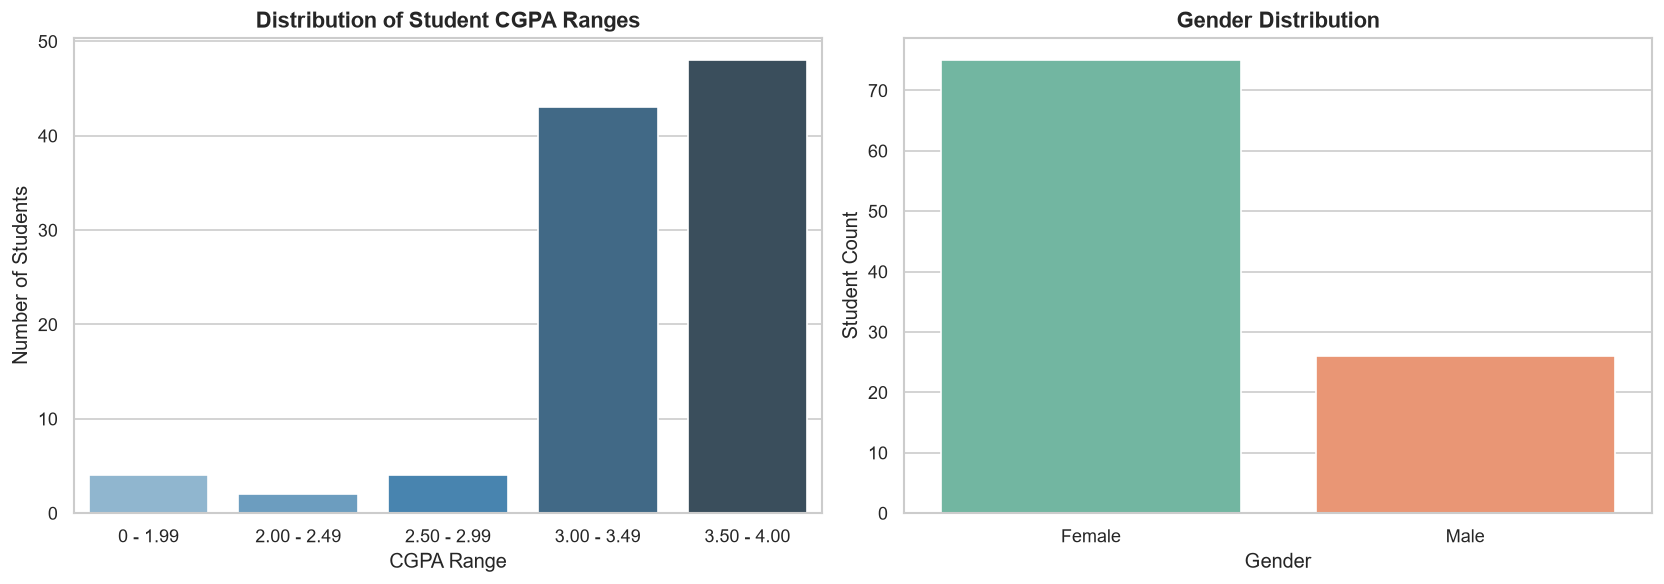

In [4]:
# Visualization 1: Demographics & CGPA Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: CGPA Band Countplot
sns.countplot(data=df_clean, x='cgpa', order=['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribution of Student CGPA Ranges', fontsize=13, fontweight='bold')
axes[0].set_xlabel('CGPA Range')
axes[0].set_ylabel('Number of Students')

# Plot B: Gender Split
sns.countplot(data=df_clean, x='gender', ax=axes[1], palette='Set2')
axes[1].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Student Count')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

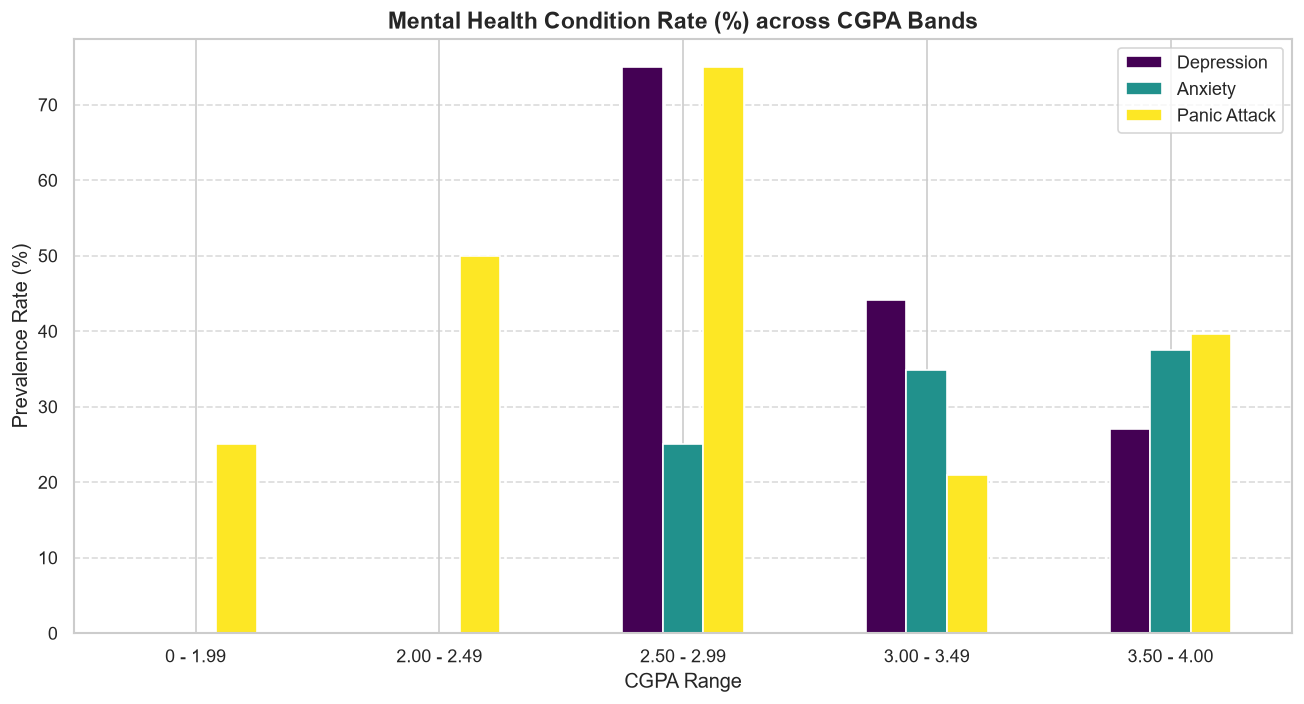

In [5]:
# Visualization 2: Mental Health Prevalence by CGPA Range
plt.figure(figsize=(10, 5))
cgpa_mental = df_clean.groupby('cgpa')[['depression', 'anxiety', 'panic_attack']].mean().reindex(
    ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
) * 100

cgpa_mental.plot(kind='bar', figsize=(11, 6), colormap='viridis')
plt.title('Mental Health Condition Rate (%) across CGPA Bands', fontsize=14, fontweight='bold')
plt.xlabel('CGPA Range')
plt.ylabel('Prevalence Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Depression', 'Anxiety', 'Panic Attack'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

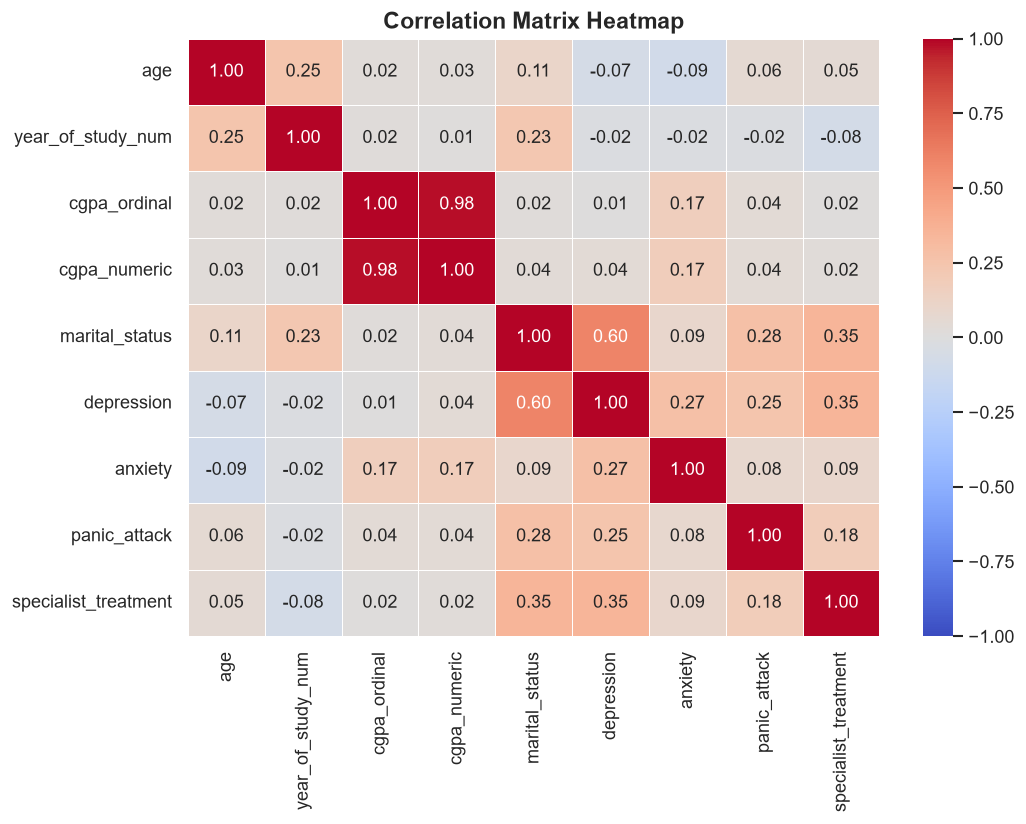

In [6]:
# Visualization 3: Correlation Matrix Heatmap
plt.figure(figsize=(9, 7))
corr_cols = ['age', 'year_of_study_num', 'cgpa_ordinal', 'cgpa_numeric', 'marital_status', 'depression', 'anxiety', 'panic_attack', 'specialist_treatment']
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Machine Learning Modeling & Hyperparameter Tuning
Compare multiple classifiers with **Stratified K-Fold Cross Validation** and tune hyperparameters using **GridSearchCV**.

In [7]:
# Run Model Training & Hyperparameter Tuning Pipeline
results_df, best_model, scaler = train_and_optimize_models(cleaned_csv_path)

# Display Model Evaluation Results
results_df.style.highlight_max(axis=0, subset=['Accuracy', 'F1-Score', 'ROC-AUC'], color='lightgreen')


      MODEL TRAINING & HYPERPARAMETER OPTIMIZATION     



-> Model: Stochastic Gradient Descent (SGD)
   Best Params: {'alpha': 0.001, 'eta0': 0.01, 'learning_rate': 'optimal', 'loss': 'modified_huber', 'penalty': 'elasticnet'}
   Test Accuracy: 0.7692 | Precision: 0.8000 | Recall: 0.4444 | F1-Score: 0.5714



-> Model: Gradient Boosting (GBM)
   Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
   Test Accuracy: 0.7692 | Precision: 0.7143 | Recall: 0.5556 | F1-Score: 0.6250

-> Model: Logistic Regression (L2/L1)
   Best Params: {'C': 1.0, 'solver': 'lbfgs'}
   Test Accuracy: 0.8077 | Precision: 1.0000 | Recall: 0.4444 | F1-Score: 0.6154



-> Model: Random Forest
   Best Params: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 25}
   Test Accuracy: 0.8462 | Precision: 1.0000 | Recall: 0.5556 | F1-Score: 0.7143

-> Model: Support Vector Machine (SVM)
   Best Params: {'C': 10.0, 'kernel': 'rbf'}
   Test Accuracy: 0.7692 | Precision: 0.7143 | Recall: 0.5556 | F1-Score: 0.6250

[BEST MODEL SELECTED]: Random Forest (Saved to models\best_model.pkl)


KeyError: "['ROC-AUC'] not in index"

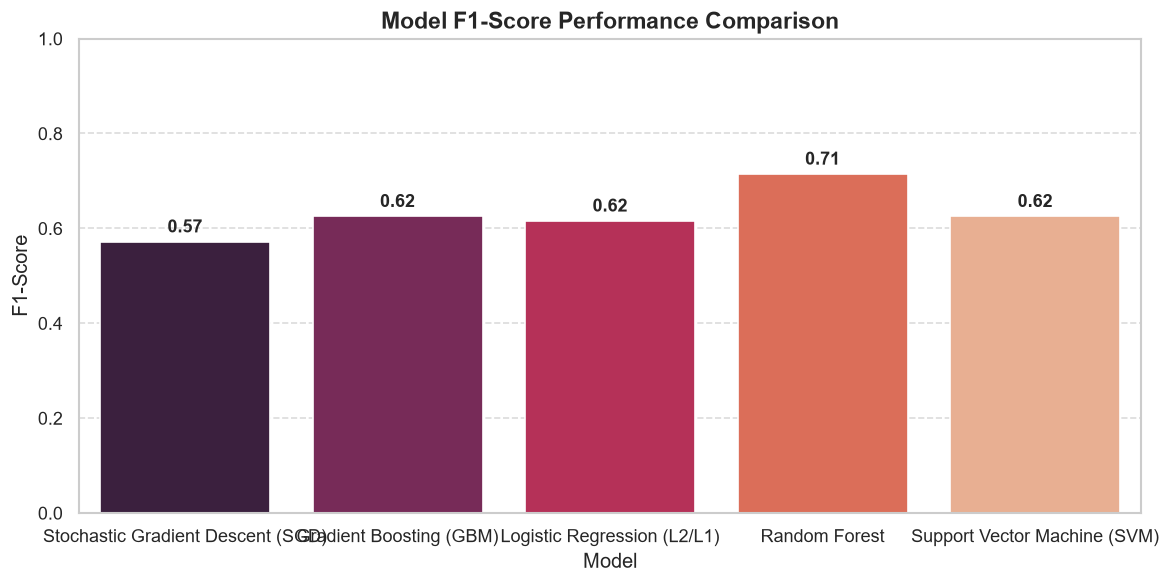

In [8]:
# Visual Model Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1-Score', palette='rocket')
plt.title('Model F1-Score Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, row in results_df.iterrows():
    plt.text(i, row['F1-Score'] + 0.02, f"{row['F1-Score']:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Key Takeaways & Project Impact
- **Data Processing Mastery**: Handled non-standard academic data, mapped CGPA ranges into ordinal continuous variables, and cleaned categorical anomalies.
- **EDA Insights**: Identifies correlations between high-stress academic bands, panic attacks, and depression rates.
- **Machine Learning Best Practices**: Implemented stratified cross-validation, feature scaling, grid search hyperparameter tuning, and saved optimal model weights (`models/best_model.pkl`) for deployment readiness.